# FASE 2 — Descarga de datos (capa v2)

> **Notebook de descarga**, dirigido por `data/catalog.yaml`. Baja el universo de datos
> **máximo y gratis** para la detección de regímenes, **sin imputar** (cada serie arranca
> en su fecha real), y deja los crudos en `data/raw/<fuente>/<serie>.parquet` +
> procedencia (`provenance.json`) + cobertura (`coverage_report.csv`).

## Decisiones (echadas a tierra)

- **Dos pistas** (ADR-001): **A** = espina histórica profunda (S&P500 + vol, ~1927/1950+,
  para tener 10+ crisis); **B** = panel rico multi-activo (crédito, curva, vol, FX,
  commodities, liquidez, macro, ~1990/2007+, para atacar el punto ciego de 2013).
- **Validación externa**: índices de estrés ya hechos (OFR FSI + subíndices, NFCI) y
  labels NBER — *ground truth laxo* de régimen.
- **Fuentes (todo gratis, verificadas una a una en FASE 2A)**:
  | Fuente | Series | Nota |
  |---|---|---|
  | **FRED** (API con key en `.env`) | ~99 | curva completa, crédito Moody's, macro, estrés |
  | **yfinance** | ~39 | índices, VIX/MOVE/VVIX, ETFs, FX, commodities |
  | **OFR** (CSV público) | 5 | Financial Stress Index + subíndices (diario 2000+) |
  | **académico** | ~9 | Ken French (factores diarios 1926+), Shiller (mensual 1871+) |
  | **github/datahub** | 5 | CSV sin auth (fallbacks) |
  | ~~stooq~~ | 2 | **bloqueado** por challenge JS (proof-of-work) → no descargable |
- **Hallazgo clave de crédito**: FRED capó las OAS de ICE BofA (`BAML*`) a ventana rodante
  de 3 años (licencia ICE, abril-2026). Sustituto histórico honesto: spreads **Moody's
  Baa-Aaa / Baa-10Y** (diarios desde 1986, sin restricción) + proxies ETF (HYG/LQD/IEF).


In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

# ROOT = raíz del repo (donde vive data/catalog.yaml)
ROOT = Path.cwd()
while not (ROOT / 'data' / 'catalog.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src import viz
viz.use_house_style()
from src.ingest import download_all, load_catalog
print('ROOT:', ROOT)

ROOT: C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM


## 1. El catálogo de datos declarado

In [2]:
cat = load_catalog()
print('meta:', {k: cat['meta'][k] for k in ('version','estado','actualizado') if k in cat['meta']})
resumen = []
for pista in ['pista_A','pista_B','validacion_externa']:
    series = (cat.get(pista) or {}).get('series', [])
    fuentes = pd.Series([s['fuente'] for s in series]).value_counts().to_dict()
    resumen.append({'pista': pista, 'n_series': len(series), 'fuentes': fuentes})
print('crisis_catalog:', len(cat['crisis_catalog']['eventos']), 'eventos')
pd.DataFrame(resumen)

meta: {'version': 1, 'estado': 'poblado_fase2', 'actualizado': datetime.date(2026, 7, 18)}
crisis_catalog: 22 eventos


,pista,n_series,fuentes
0,pista_A,79,"{'fred': 55, 'yfinance': 13, 'academico': 9, '..."
1,pista_B,64,"{'yfinance': 32, 'fred': 29, 'github': 3}"
2,validacion_externa,25,"{'fred': 15, 'ofr': 5, 'academico': 2, 'yfinan..."


## 2. Descarga

La descarga la ejecuta el módulo reproducible **`python -m src.ingest.download`**
(dirigido por el catálogo, cacheado, resiliente por serie). Aquí cargamos el
`coverage_report.csv` que produjo para documentar y visualizar el resultado. Para
re-descargar desde cero: `download_all(force=True)`.

In [3]:
rep = pd.read_csv(ROOT / 'data' / 'raw' / 'coverage_report.csv')
print('Estado de la descarga:')
print(rep['status'].value_counts().to_string())
ok = rep['status'].isin(['OK','CACHE']).sum()
print(f'\n>>> {ok}/{len(rep)} series disponibles en disco')

Estado de la descarga:
status
CACHE    160
ERROR      8

>>> 160/168 series disponibles en disco


In [4]:
# Detalle por fuente y estado
tab = rep.pivot_table(index='fuente', columns='status', values='nombre',
                      aggfunc='count', fill_value=0)
tab['total'] = tab.sum(axis=1)
tab

status,CACHE,ERROR,total
fuente,,,
academico,7,4,11
fred,99,0,99
github,3,2,5
ofr,5,0,5
stooq,0,2,2
yfinance,46,0,46


In [5]:
# Series que fallaron (transparencia total)
err = rep[rep['status']=='ERROR']
if len(err):
    print(f'{len(err)} series con ERROR:')
    for _, r in err.iterrows():
        print("  - {:26} ({}) {}".format(r['nombre'], r['fuente'], str(r.get('error',''))[:80]))
else:
    print('Sin errores.')

8 series con ERROR:
  - GW_PREDICTORS_QUARTERLY    (academico) DateParseError: year 18711 is out of range: 18711
  - JST_MACROHISTORY_R6        (academico) RuntimeError: JST macrohistory xlsx no accesible
  - DOW_STOOQ_DEEP             (stooq) RuntimeError: stooq bloqueado por challenge JS (proof-of-work); no descargable
  - GH_SP500_CONSTITUENTS_PIT  (github) RuntimeError: github fja05680/sp500:S&P 500 Historical Components & Changes: no 
  - GH_SP500_CONSTITUENTS_NOW  (github) RuntimeError: github datasets/s-and-p-500-companies:data/constituents.csv: no es
  - PHILLY_ANXIOUS_INDEX       (academico) ValueError: Excel file format cannot be determined, you must specify an engine m
  - JST_CRISIS_GROUNDTRUTH     (academico) RuntimeError: JST macrohistory xlsx no accesible
  - SP500_STOOQ_FALLBACK       (stooq) RuntimeError: stooq bloqueado por challenge JS (proof-of-work); no descargable


## 3. Cobertura temporal (¿cuánta historia tiene cada serie?)

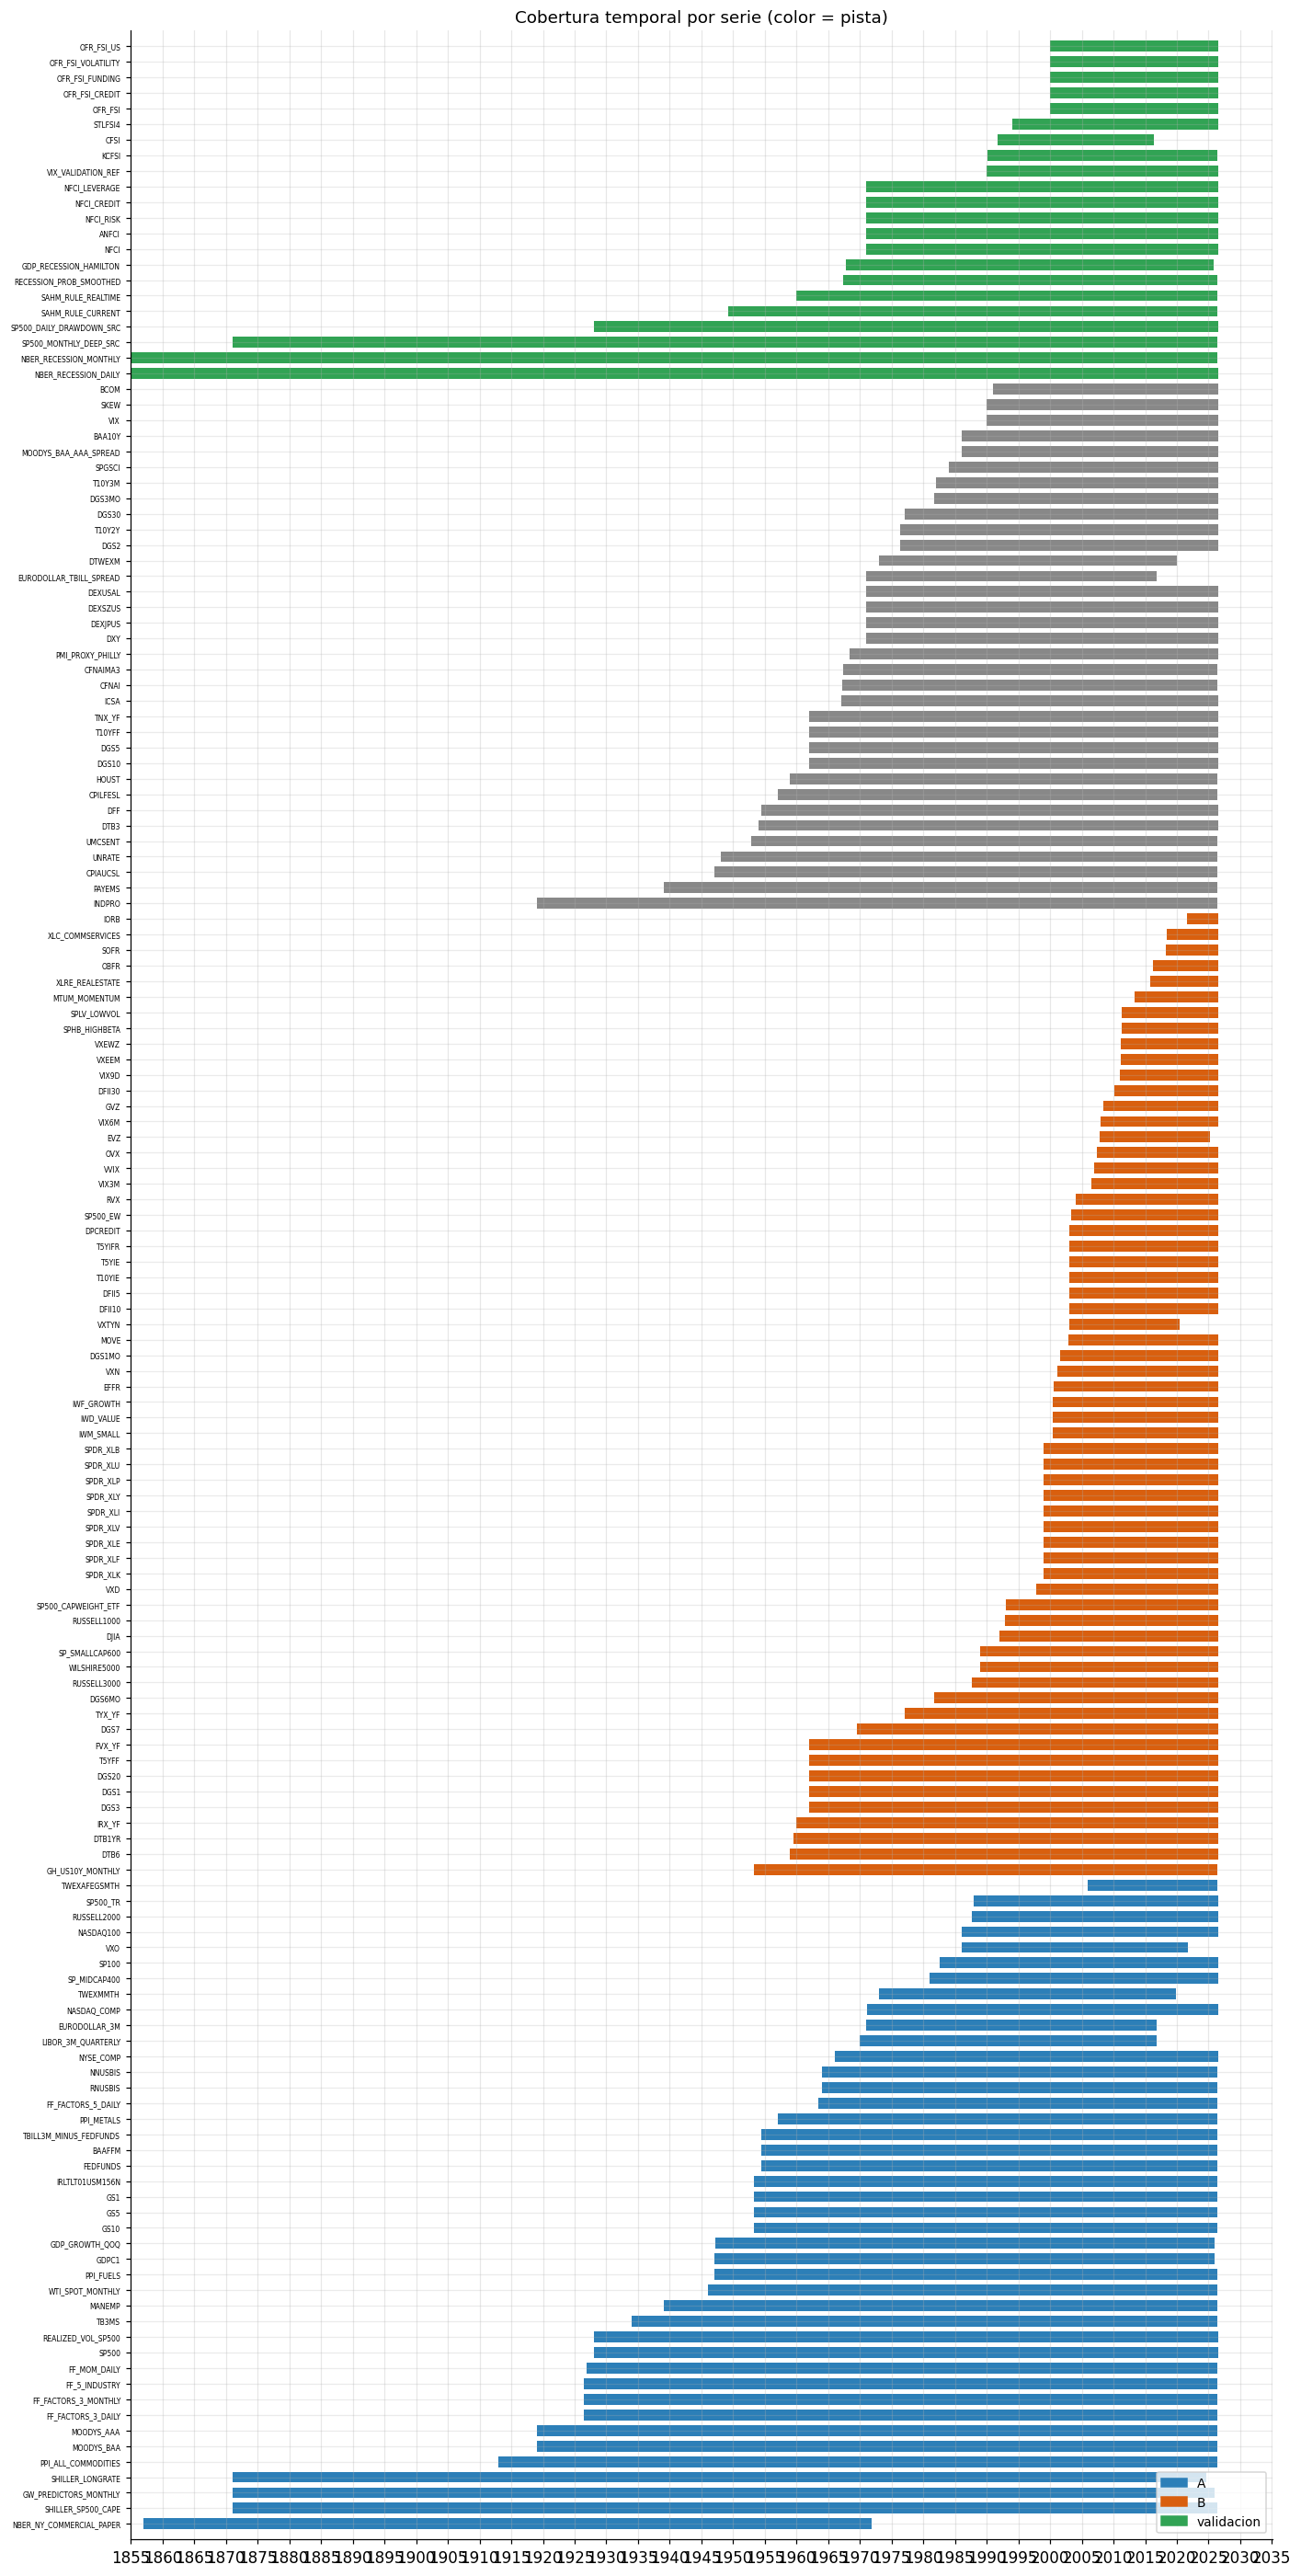

In [6]:
ok_rep = rep[rep['status'].isin(['OK','CACHE'])].copy()
ok_rep['inicio'] = pd.to_datetime(ok_rep['inicio'])
ok_rep['fin'] = pd.to_datetime(ok_rep['fin'])
ok_rep = ok_rep.sort_values(['pista','inicio'])

colores = {'A':'#2c7fb8', 'B':'#d95f0e', 'validacion':'#31a354'}
fig, ax = plt.subplots(figsize=(13, max(6, len(ok_rep)*0.16)))
for i, (_, r) in enumerate(ok_rep.iterrows()):
    ax.barh(i, (r['fin']-r['inicio']).days, left=r['inicio'],
            color=colores.get(r['pista'], '#888'), height=0.7)
ax.set_yticks(range(len(ok_rep)))
ax.set_yticklabels(ok_rep['nombre'], fontsize=5)
ax.set_ylim(-1, len(ok_rep))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=p) for p,c in colores.items()], loc='lower right')
ax.set_title('Cobertura temporal por serie (color = pista)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

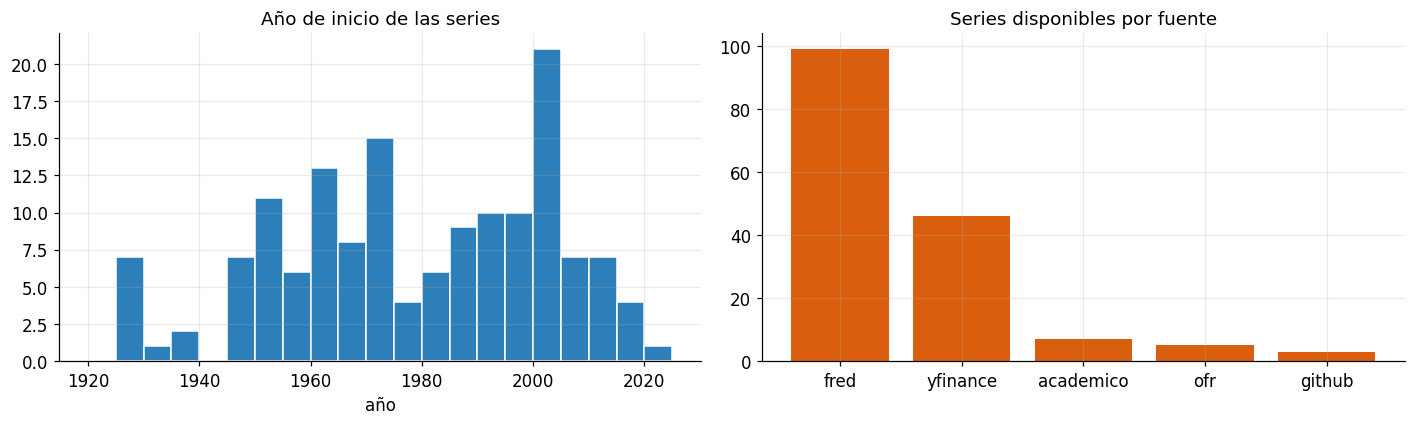

Serie más profunda: NBER_RECESSION_DAILY -> 1854-12-01


In [7]:
# Histograma de profundidad histórica (año de inicio)
fig, axes = plt.subplots(1, 2, figsize=(13,4))
ok_rep['anio_inicio'] = ok_rep['inicio'].dt.year
axes[0].hist(ok_rep['anio_inicio'], bins=range(1920,2030,5), color='#2c7fb8', edgecolor='white')
axes[0].set_title('Año de inicio de las series'); axes[0].set_xlabel('año')
cnt = ok_rep['fuente'].value_counts()
axes[1].bar(cnt.index, cnt.values, color='#d95f0e')
axes[1].set_title('Series disponibles por fuente')
plt.tight_layout(); plt.show()
print('Serie más profunda:', ok_rep.loc[ok_rep['inicio'].idxmin(),'nombre'],
      '->', ok_rep['inicio'].min().date())

## 4. Catálogo de crisis (ataca el n≈4 de la Capa 1)

22 eventos de crisis catalogados (1929-2025)


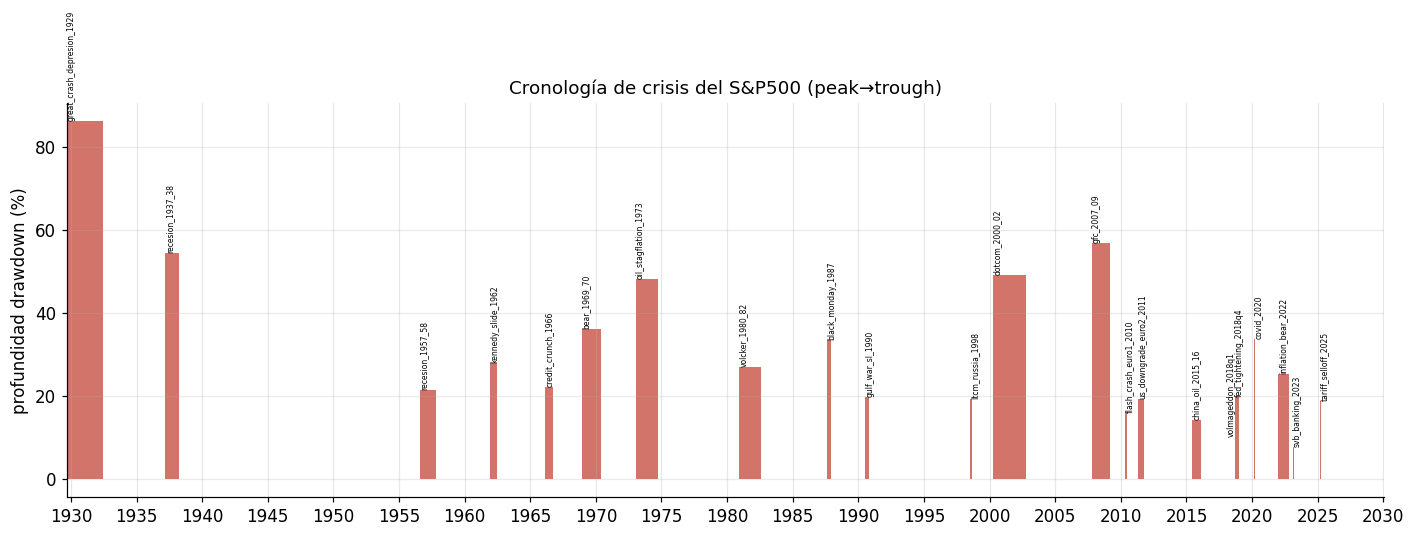

,name,peak,trough,depth,tipo,nber
20,great_crash_depresion_1929,1929-09-16,1932-06-01,-0.862,crash,True
21,recesion_1937_38,1937-03-10,1938-03-31,-0.545,bear,True
0,recesion_1957_58,1956-08-02,1957-10-22,-0.215,bear,True
1,kennedy_slide_1962,1961-12-12,1962-06-26,-0.280,bear,False
2,credit_crunch_1966,1966-02-09,1966-10-07,-0.222,bear,False
3,bear_1969_70,1968-11-29,1970-05-26,-0.361,bear,True
4,oil_stagflation_1973,1973-01-11,1974-10-03,-0.482,bear,True
5,volcker_1980_82,1980-11-28,1982-08-12,-0.271,bear,True
6,black_monday_1987,1987-08-25,1987-12-04,-0.335,crash,False
7,gulf_war_sl_1990,1990-07-16,1990-10-11,-0.199,correction,True


In [8]:
ev = pd.DataFrame(cat['crisis_catalog']['eventos'])
ev['peak'] = pd.to_datetime(ev['peak']); ev['trough'] = pd.to_datetime(ev['trough'])
ev = ev.sort_values('peak')
print(f'{len(ev)} eventos de crisis catalogados ({ev.peak.dt.year.min()}-{ev.peak.dt.year.max()})')
fig, ax = plt.subplots(figsize=(13,5))
for _, r in ev.iterrows():
    ax.barh(0, (r['trough']-r['peak']).days, left=r['peak'],
            height=abs(r['depth'])*100, align='edge',
            color='#c0392b', alpha=0.7)
    ax.text(r['peak'], abs(r['depth'])*100, r['name'], rotation=90,
            fontsize=5, va='bottom', ha='left')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylabel('profundidad drawdown (%)'); ax.set_title('Cronología de crisis del S&P500 (peak→trough)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()
ev[['name','peak','trough','depth','tipo','nber']]

## 5. Cierre

- Los crudos quedan en `data/raw/<fuente>/<serie>.parquet` (gitignored), con
  `provenance.json` (checksum + procedencia por serie) y `coverage_report.csv` versionados.
- **Siguiente**: FASE 3 (EDA + análisis) sobre estas series → definir las features causales
  v2 y **congelar el benchmark por pista**.
- Todo lo no descargable (stooq, algún académico) queda **declarado** en el coverage, no
  omitido en silencio.
